# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [4]:
# 设置任务参数
name = "300_mlp"
index_symbol: str = "000300.SSE"
start: str = "2007-01-01"
end: str = "2024-10-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

In [6]:
print(component_symbols)

['001228.SZSE', '002529.SZSE', '002524.SZSE', '002549.SZSE', '000566.SZSE', '300459.SZSE', '301413.SZSE', '600476.SSE', '002956.SZSE', '002918.SZSE', '002943.SZSE', '002005.SZSE', '601011.SSE', '301548.SZSE', '002135.SZSE', '601100.SSE', '002145.SZSE', '300260.SZSE', '002020.SZSE', '600337.SSE', '300122.SZSE', '000591.SZSE', '603058.SSE', '300655.SZSE', '002853.SZSE', '300480.SZSE', '600241.SSE', '002141.SZSE', '000811.SZSE', '301040.SZSE', '300559.SZSE', '603439.SSE', '600101.SSE', '600859.SSE', '603826.SSE', '600740.SSE', '300788.SZSE', '003035.SZSE', '300121.SZSE', '300720.SZSE', '301678.SZSE', '300244.SZSE', '301235.SZSE', '002605.SZSE', '603690.SSE', '300667.SZSE', '002371.SZSE', '000593.SZSE', '300534.SZSE', '301046.SZSE', '300071.SZSE', '688199.SSE', '002567.SZSE', '002069.SZSE', '301552.SZSE', '301139.SZSE', '603808.SSE', '600792.SSE', '603879.SSE', '000755.SZSE', '301209.SZSE', '300043.SZSE', '301318.SZSE', '001222.SZSE', '300810.SZSE', '001215.SZSE', '300988.SZSE', '301032.SZ

# 特征计算

In [7]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [8]:
# 加载成分股数据
component_symbols=component_symbols[:500]
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

2025-10-22 18:21:33 File lab/csi300/daily/301678.SZSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/603202.SSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/301560.SZSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/603124.SSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/301622.SZSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/001390.SZSE.parquet does not exist
2025-10-22 18:21:34 File lab/csi300/daily/688411.SSE.parquet does not exist
2025-10-22 18:21:35 File lab/csi300/daily/603406.SSE.parquet does not exist


In [9]:
# 设置数据时间段
train_period: tuple[str, str] = ("2007-01-01", "2020-12-31")
valid_period: tuple[str, str] = ("2021-01-01", "2021-12-31")
test_period: tuple[str, str] = ("2022-01-01", "2024-10-31")

In [10]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [11]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])
print(f"fit_start_time: {fit_start_time}")
print(f"fit_end_time: {fit_end_time}")
dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

fit_start_time: 2007-01-01 00:00:00
fit_end_time: 2020-12-31 00:00:00


In [12]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [13]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

2025-10-22 18:36:12 开始计算表达式因子特征


  1%|          | 1/159 [00:02<06:29,  2.47s/it]

Feature calculation kmid took: 0.010710954666137695 seconds | (close - open) / open
Feature calculation kmid_2 took: 0.009596109390258789 seconds | (close - open) / (high - low + 1e-12)Feature calculation klen took: 0.0067501068115234375 seconds | (high - low) / open



  3%|▎         | 4/159 [00:02<01:30,  1.71it/s]

Feature calculation kup took: 0.19768929481506348 seconds | (high - ts_greater(open, close)) / open
Feature calculation kup_2 took: 0.1663060188293457 seconds | (high - ts_greater(open, close)) / (high - low + 1e-12)


...

100%|██████████| 159/159 [21:33<00:00,  8.13s/it]

Feature calculation wvma_60 took: 87.8086678981781 seconds | ts_std(ts_abs(close / ts_delay(close, 1) - 1) * volume, 60) / (ts_mean(ts_abs(close / ts_delay(close, 1) - 1) * volume, 60) + 1e-12)
2025-10-22 18:57:46 开始合并结果数据因子特征



0it [00:00, ?it/s]


2025-10-22 18:57:47 开始筛选成分股数据


100%|██████████| 5153/5153 [00:26<00:00, 191.68it/s]


Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.266367,1.216764,0.831362,0.095568,105882,10.165010
2.0,0.551833,1.396620,0.922621,0.068528,104051,9.989228
3.0,0.609963,1.482150,0.960792,0.069396,103556,9.941707
4.0,0.655610,1.630530,0.987894,0.072031,103979,9.982316
5.0,0.685704,1.744599,1.010054,0.075112,104320,10.015053
6.0,0.708655,1.795863,1.030300,0.078659,103360,9.922890
7.0,0.743148,1.879580,1.050262,0.082900,103584,9.944395
8.0,0.777929,1.964495,1.072824,0.088263,103951,9.979628
9.0,0.803515,2.064144,1.103099,0.096418,103657,9.951403


Returns Analysis


,1D,5D,10D
Ann. alpha,-0.007,0.060,0.059
beta,0.058,0.065,0.052
Mean Period Wise Return Top Quantile (bps),3.367,4.291,3.218
Mean Period Wise Return Bottom Quantile (bps),-0.494,-4.370,-4.135
Mean Period Wise Spread (bps),3.861,8.908,7.642


<Figure size 640x480 with 0 Axes>

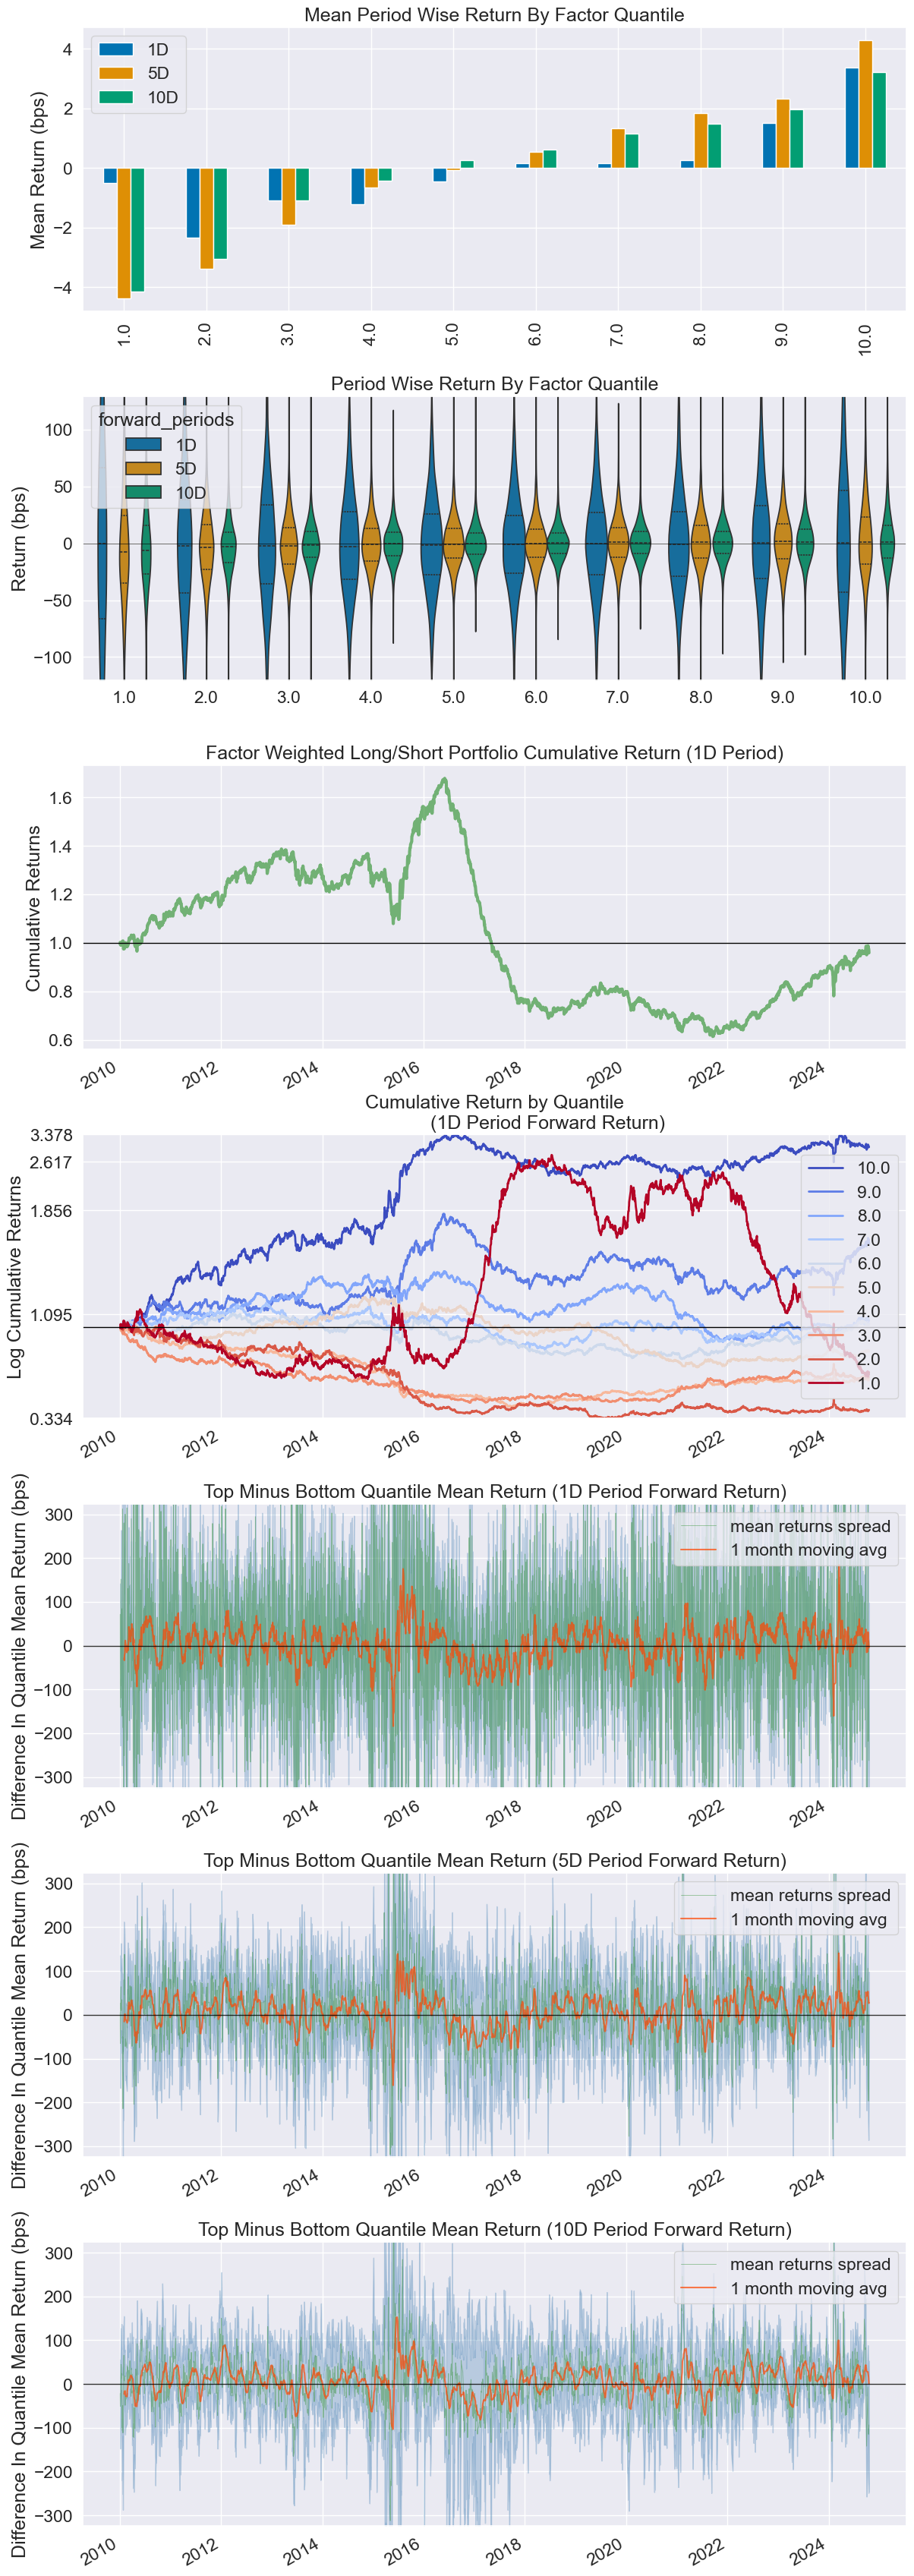

Information Analysis


,1D,5D,10D
IC Mean,0.042,0.063,0.069
IC Std.,0.174,0.168,0.165
Risk-Adjusted IC,0.240,0.374,0.415
t-stat(IC),14.395,22.434,24.868
p-value(IC),0.000,0.000,0.000
IC Skew,0.031,0.119,0.210
IC Kurtosis,0.264,0.374,0.170


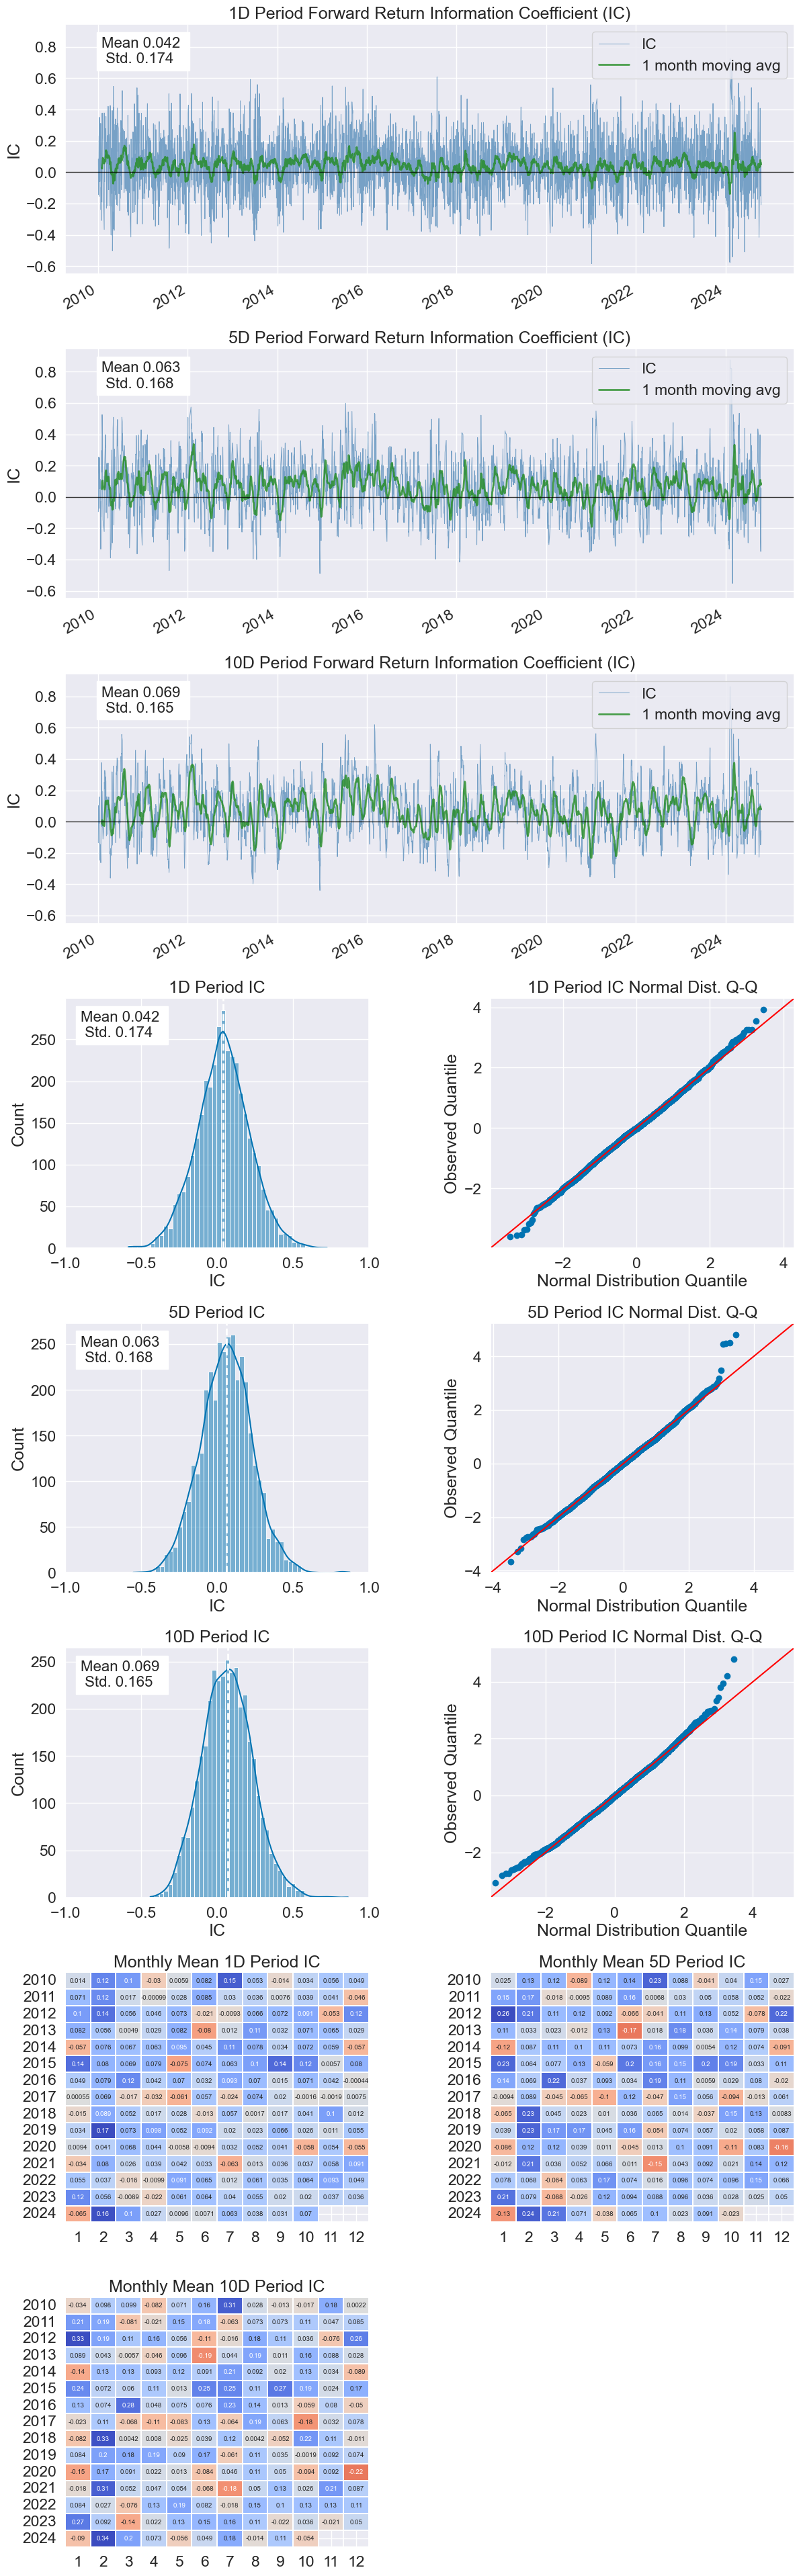

/Users/guangshengkuang/Desktop/learning/token_vn/.venv/lib/python3.13/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.163,0.363,0.499
Quantile 2.0 Mean Turnover,0.387,0.660,0.756
Quantile 3.0 Mean Turnover,0.486,0.733,0.809
Quantile 4.0 Mean Turnover,0.530,0.761,0.826
Quantile 5.0 Mean Turnover,0.543,0.767,0.834
Quantile 6.0 Mean Turnover,0.542,0.765,0.828
Quantile 7.0 Mean Turnover,0.518,0.751,0.822
Quantile 8.0 Mean Turnover,0.461,0.712,0.793
Quantile 9.0 Mean Turnover,0.362,0.626,0.733
Quantile 10.0 Mean Turnover,0.152,0.340,0.471


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.963,0.833,0.696


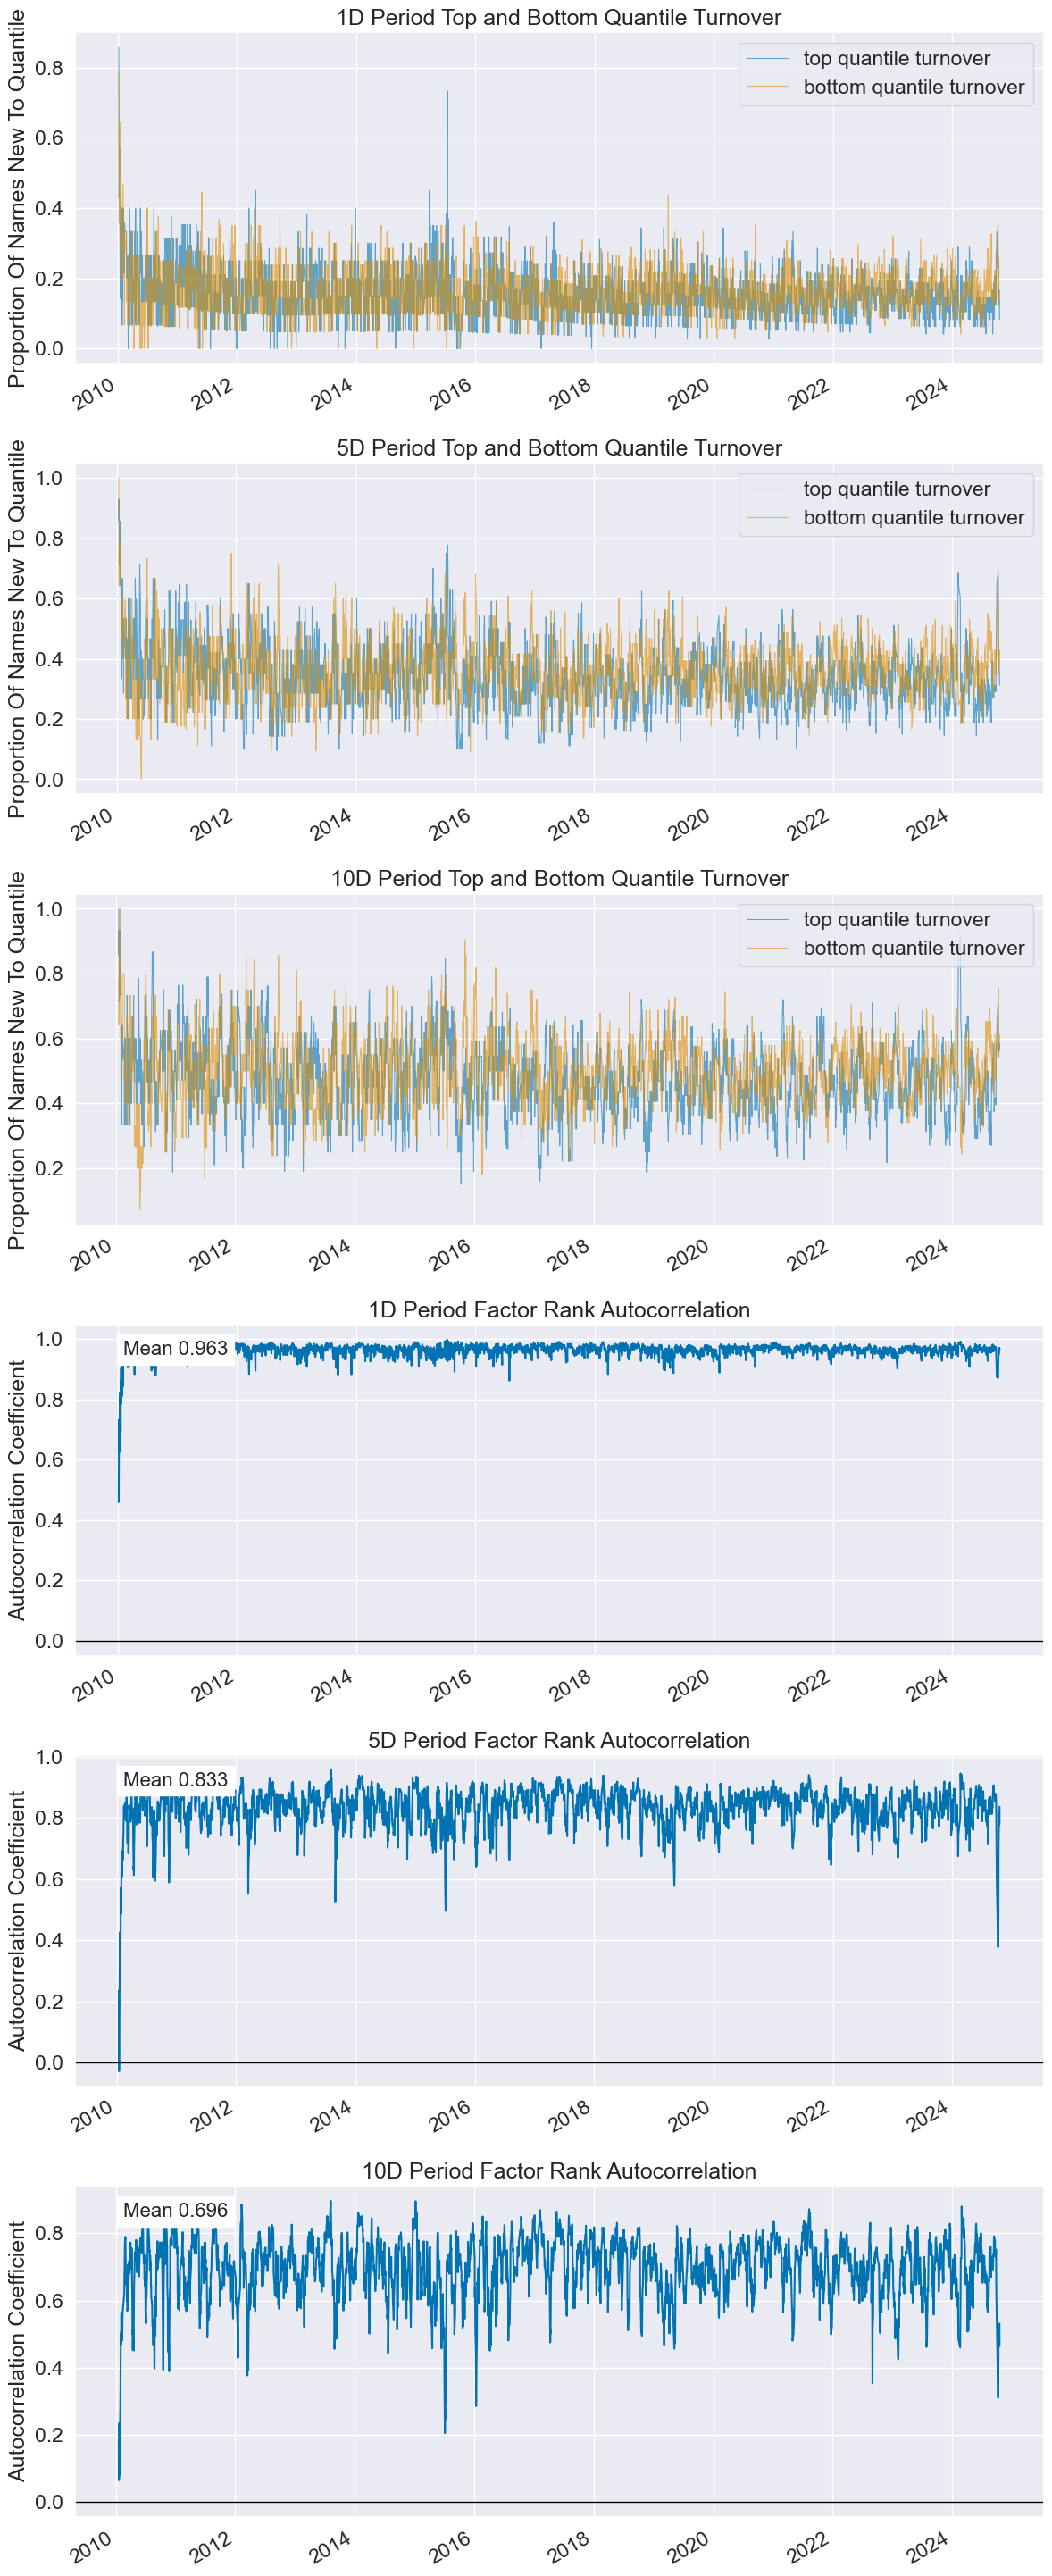

In [14]:
# 特征表现分析
dataset.show_feature_performance("ma_60")

In [15]:
dataset.df.shape

(1046578, 10)

In [16]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [17]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.mlp_model import MlpModel

In [18]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [19]:
dataset.df.shape

(1046578, 10)

In [20]:
# 创建模型对象
kwargs = {
    "input_size": 158,
    "hidden_sizes": (256,),
    "lr": 0.002,
    "optimizer": "adam",
    "n_epochs": 8000,
    "batch_size": 8192,
    "weight_decay": 0.0002,
    "seed": 42
}

model: AlphaModel = MlpModel(**kwargs)

In [21]:
from vnpy.alpha import Segment
df_train = dataset.fetch_learn(Segment.TRAIN)
print("TRAIN shape:", df_train.shape)
print(df_train.head())
print("TRAIN unique symbols:", df_train["vt_symbol"].unique()[:20])
print("TRAIN dates:", df_train["datetime"].min(), df_train["datetime"].max())

TRAIN shape: (631774, 161)
shape: (5, 161)
┌────────────┬────────────┬───────────┬───────────┬───┬──────────┬──────────┬──────────┬───────────┐
│ datetime   ┆ vt_symbol  ┆ kmid      ┆ klen      ┆ … ┆ vsumd_20 ┆ vsumd_30 ┆ vsumd_60 ┆ label     │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ datetime[μ ┆ str        ┆ f64       ┆ f64       ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
│ s]         ┆            ┆           ┆           ┆   ┆          ┆          ┆          ┆           │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪══════════╪══════════╪══════════╪═══════════╡
│ 2010-01-04 ┆ 000006.SZS ┆ -0.97312  ┆ -0.633986 ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ 0.890441  │
│ 00:00:00   ┆ E          ┆           ┆           ┆   ┆          ┆          ┆          ┆           │
│ 2010-01-04 ┆ 000058.SZS ┆ -0.059392 ┆ 1.165026  ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ 1.551912  │
│ 00:00:00   ┆ E          ┆           ┆         

In [22]:
# 使用数据集训练模型
model.fit(dataset)

2025-10-22 19:02:07 [Step 20]: train_loss 1.230842, valid_loss 1.071477
2025-10-22 19:02:07 	验证集损失从 inf 降低到 1.071477


/Users/guangshengkuang/Desktop/learning/token_vn/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1344: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


2025-10-22 19:02:08 [Step 40]: train_loss 1.079760, valid_loss 1.025586
2025-10-22 19:02:08 	验证集损失从 1.071477 降低到 1.025586
2025-10-22 19:02:08 [Step 60]: train_loss 1.047510, valid_loss 1.011322
2025-10-22 19:02:08 	验证集损失从 1.025586 降低到 1.011322
2025-10-22 19:02:09 [Step 80]: train_loss 1.035962, valid_loss 1.008750
2025-10-22 19:02:09 	验证集损失从 1.011322 降低到 1.008750
2025-10-22 19:02:09 [Step 100]: train_loss 1.026991, valid_loss 1.003852
2025-10-22 19:02:09 	验证集损失从 1.008750 降低到 1.003852
2025-10-22 19:02:10 [Step 120]: train_loss 1.020684, valid_loss 1.007663
2025-10-22 19:02:10 [Step 140]: train_loss 1.010147, valid_loss 1.002994
2025-10-22 19:02:10 	验证集损失从 1.003852 降低到 1.002994
2025-10-22 19:02:11 [Step 160]: train_loss 1.006213, valid_loss 1.000640
2025-10-22 19:02:11 	验证集损失从 1.002994 降低到 1.000640
2025-10-22 19:02:11 [Step 180]: train_loss 1.003788, valid_loss 0.996931
2025-10-22 19:02:11 	验证集损失从 1.000640 降低到 0.996931
2025-10-22 19:02:12 [Step 200]: train_loss 1.005478, valid_loss 0.999

In [23]:
# 查看模型细节
model.detail()

2025-10-22 19:02:44 输入特征维度: 158
2025-10-22 19:02:44 隐藏层大小: (256,)
2025-10-22 19:02:44 模型总参数量: 41,473
2025-10-22 19:02:44 训练设备: cpu
2025-10-22 19:02:44 当前学习率: 0.002
2025-10-22 19:02:44 批次大小: 8192


,Importance
Feature,
rank_5,0.002710
max_10,0.001550
resi_5,0.001517
max_30,0.001509
roc_5,0.001502
...,...
imax_60,0.000560
cntp_10,0.000557
imxd_30,0.000556


In [24]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [25]:
model: AlphaModel = lab.load_model(name)

In [26]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.5% entries from factor data: 1.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.803037,-0.063505,-0.256604,0.104732,31732,10.151933
2,-0.505567,0.033160,-0.112486,0.051221,31187,9.977573
3,-0.468149,0.072858,-0.056885,0.045881,31161,9.969255
4,-0.438517,0.111783,-0.019541,0.044608,31187,9.977573
5,-0.402887,0.151912,0.010725,0.043823,31281,10.007646
6,-0.372770,0.179922,0.037756,0.043541,31152,9.966376
7,-0.348990,0.211394,0.064174,0.043487,31140,9.962537
8,-0.320013,0.244703,0.092583,0.043972,31208,9.984292
9,-0.287153,0.293489,0.127177,0.044919,31141,9.962856


Returns Analysis


,1D,5D,10D
Ann. alpha,0.582,0.342,0.247
beta,-0.027,-0.019,-0.005
Mean Period Wise Return Top Quantile (bps),13.831,7.489,5.743
Mean Period Wise Return Bottom Quantile (bps),-30.270,-21.387,-16.325
Mean Period Wise Spread (bps),44.101,29.046,22.227


<Figure size 640x480 with 0 Axes>

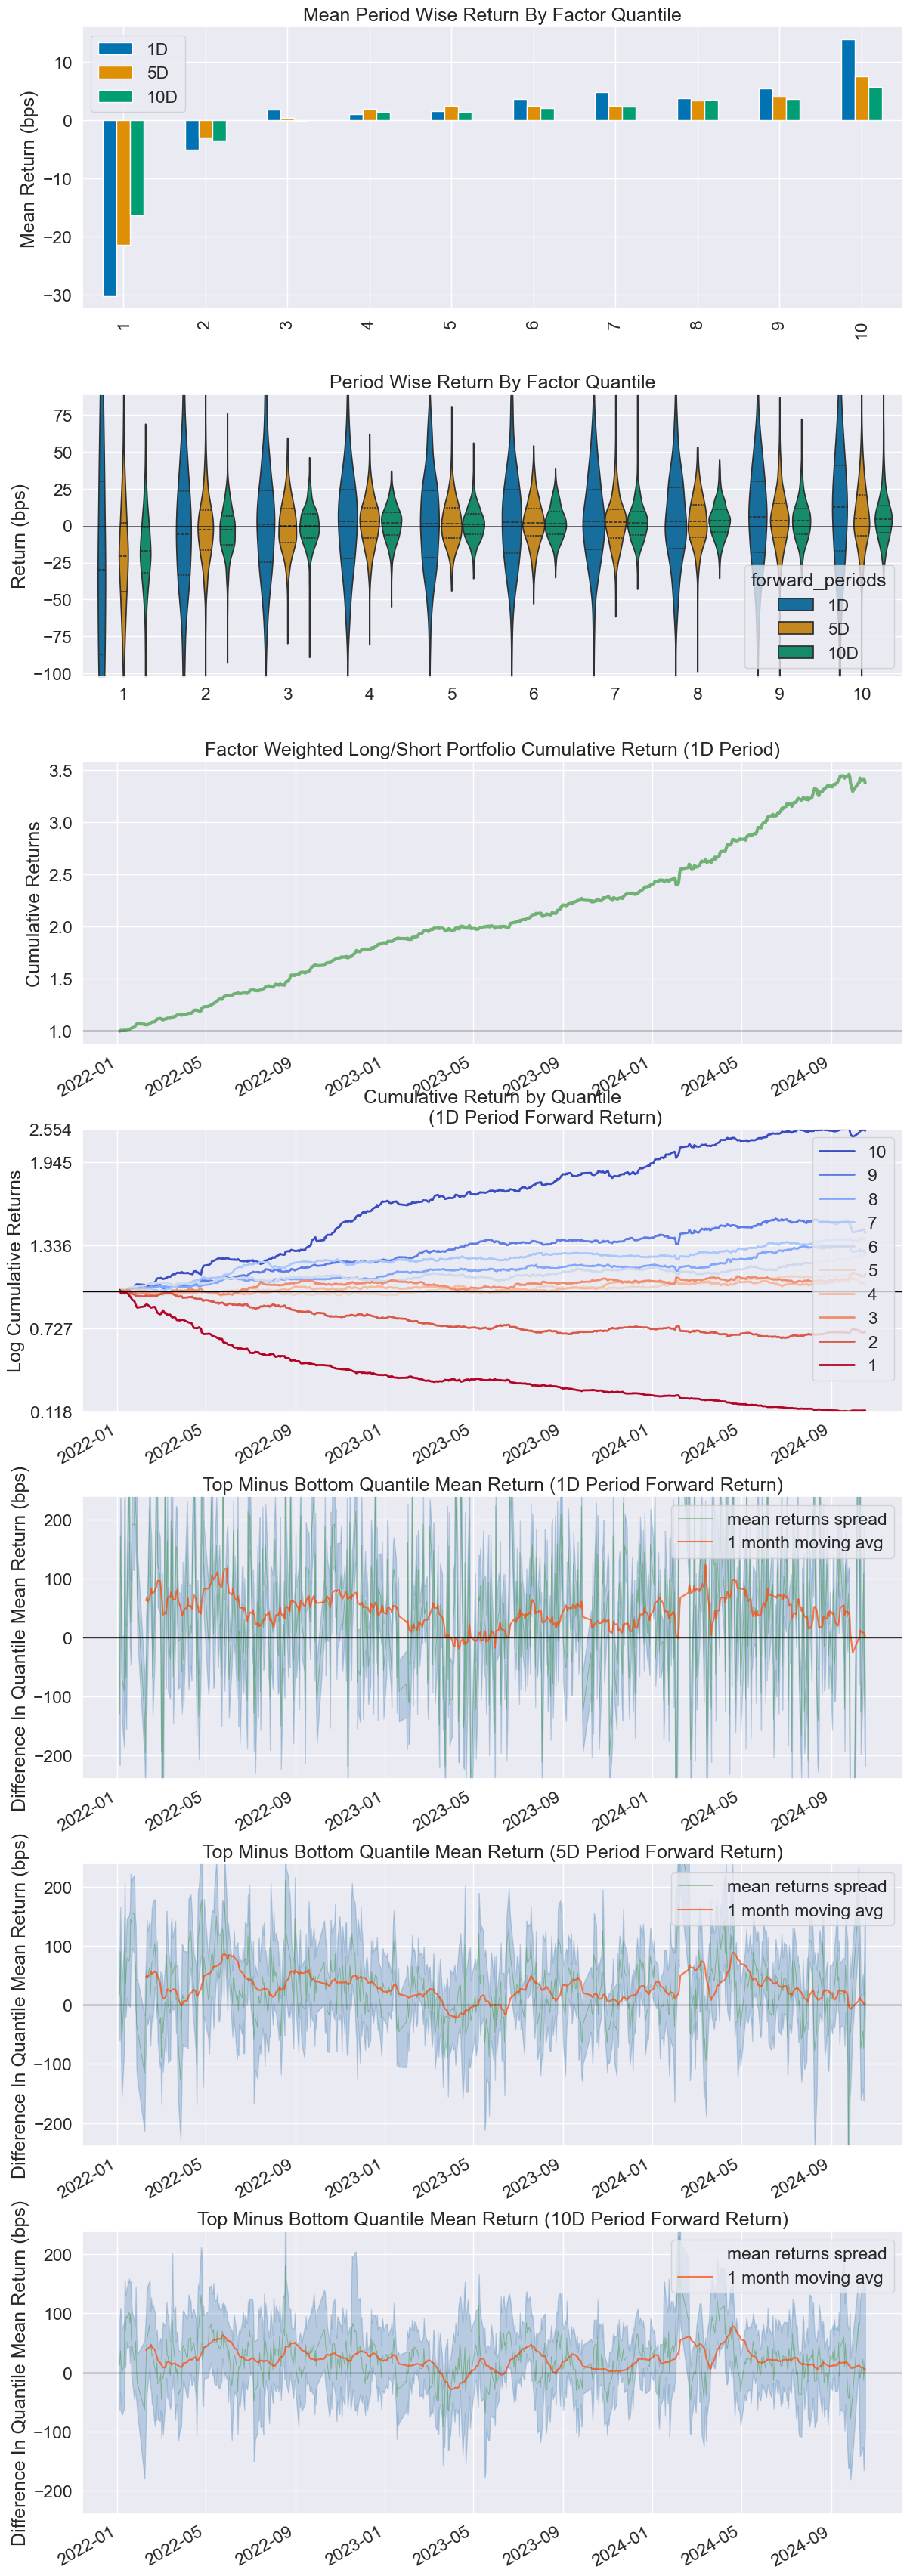

Information Analysis


,1D,5D,10D
IC Mean,0.071,0.082,0.088
IC Std.,0.108,0.105,0.106
Risk-Adjusted IC,0.655,0.779,0.832
t-stat(IC),17.003,20.218,21.588
p-value(IC),0.000,0.000,0.000
IC Skew,-0.278,-0.007,0.126
IC Kurtosis,1.037,0.043,0.172


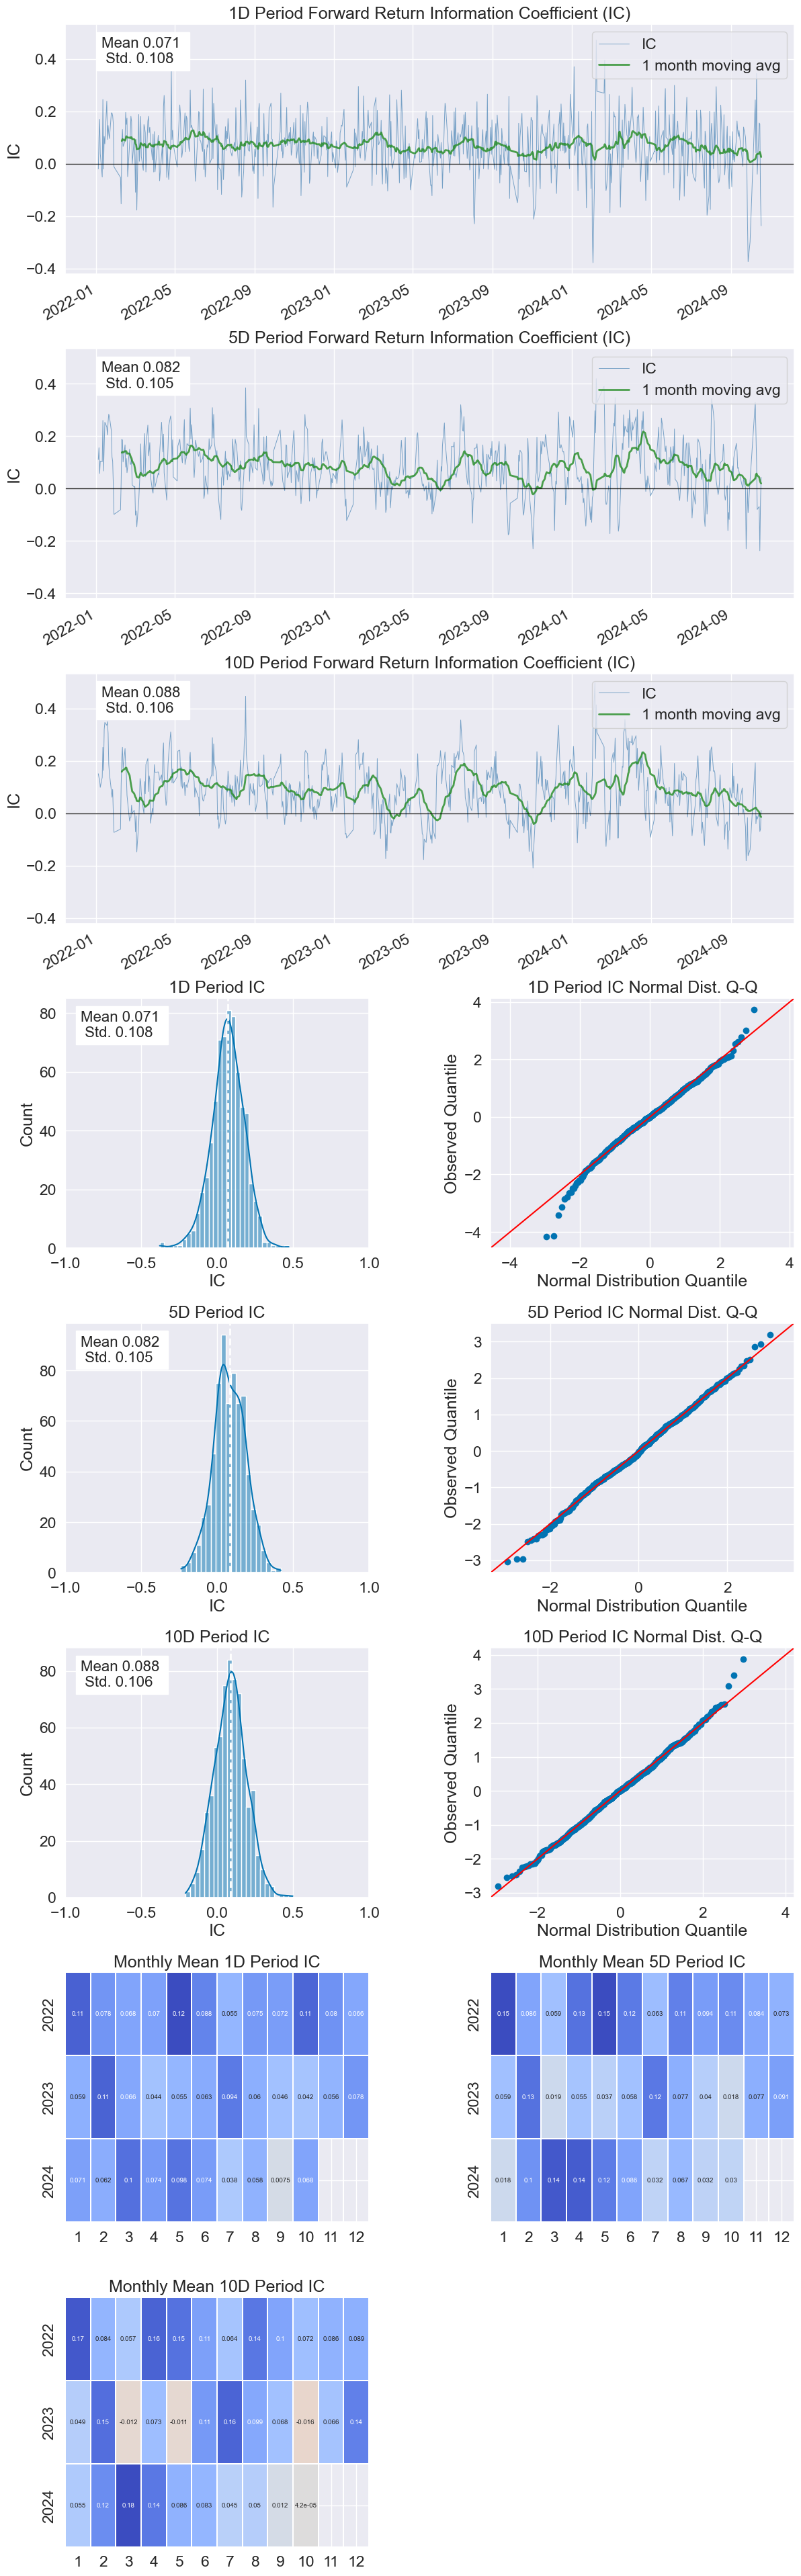

/Users/guangshengkuang/Desktop/learning/token_vn/.venv/lib/python3.13/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.423,0.703,0.771
Quantile 2 Mean Turnover,0.725,0.845,0.860
Quantile 3 Mean Turnover,0.794,0.870,0.879
Quantile 4 Mean Turnover,0.823,0.879,0.888
Quantile 5 Mean Turnover,0.835,0.883,0.892
Quantile 6 Mean Turnover,0.841,0.886,0.889
Quantile 7 Mean Turnover,0.833,0.881,0.887
Quantile 8 Mean Turnover,0.808,0.867,0.881
Quantile 9 Mean Turnover,0.763,0.848,0.862
Quantile 10 Mean Turnover,0.532,0.762,0.809


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.698,0.346,0.254


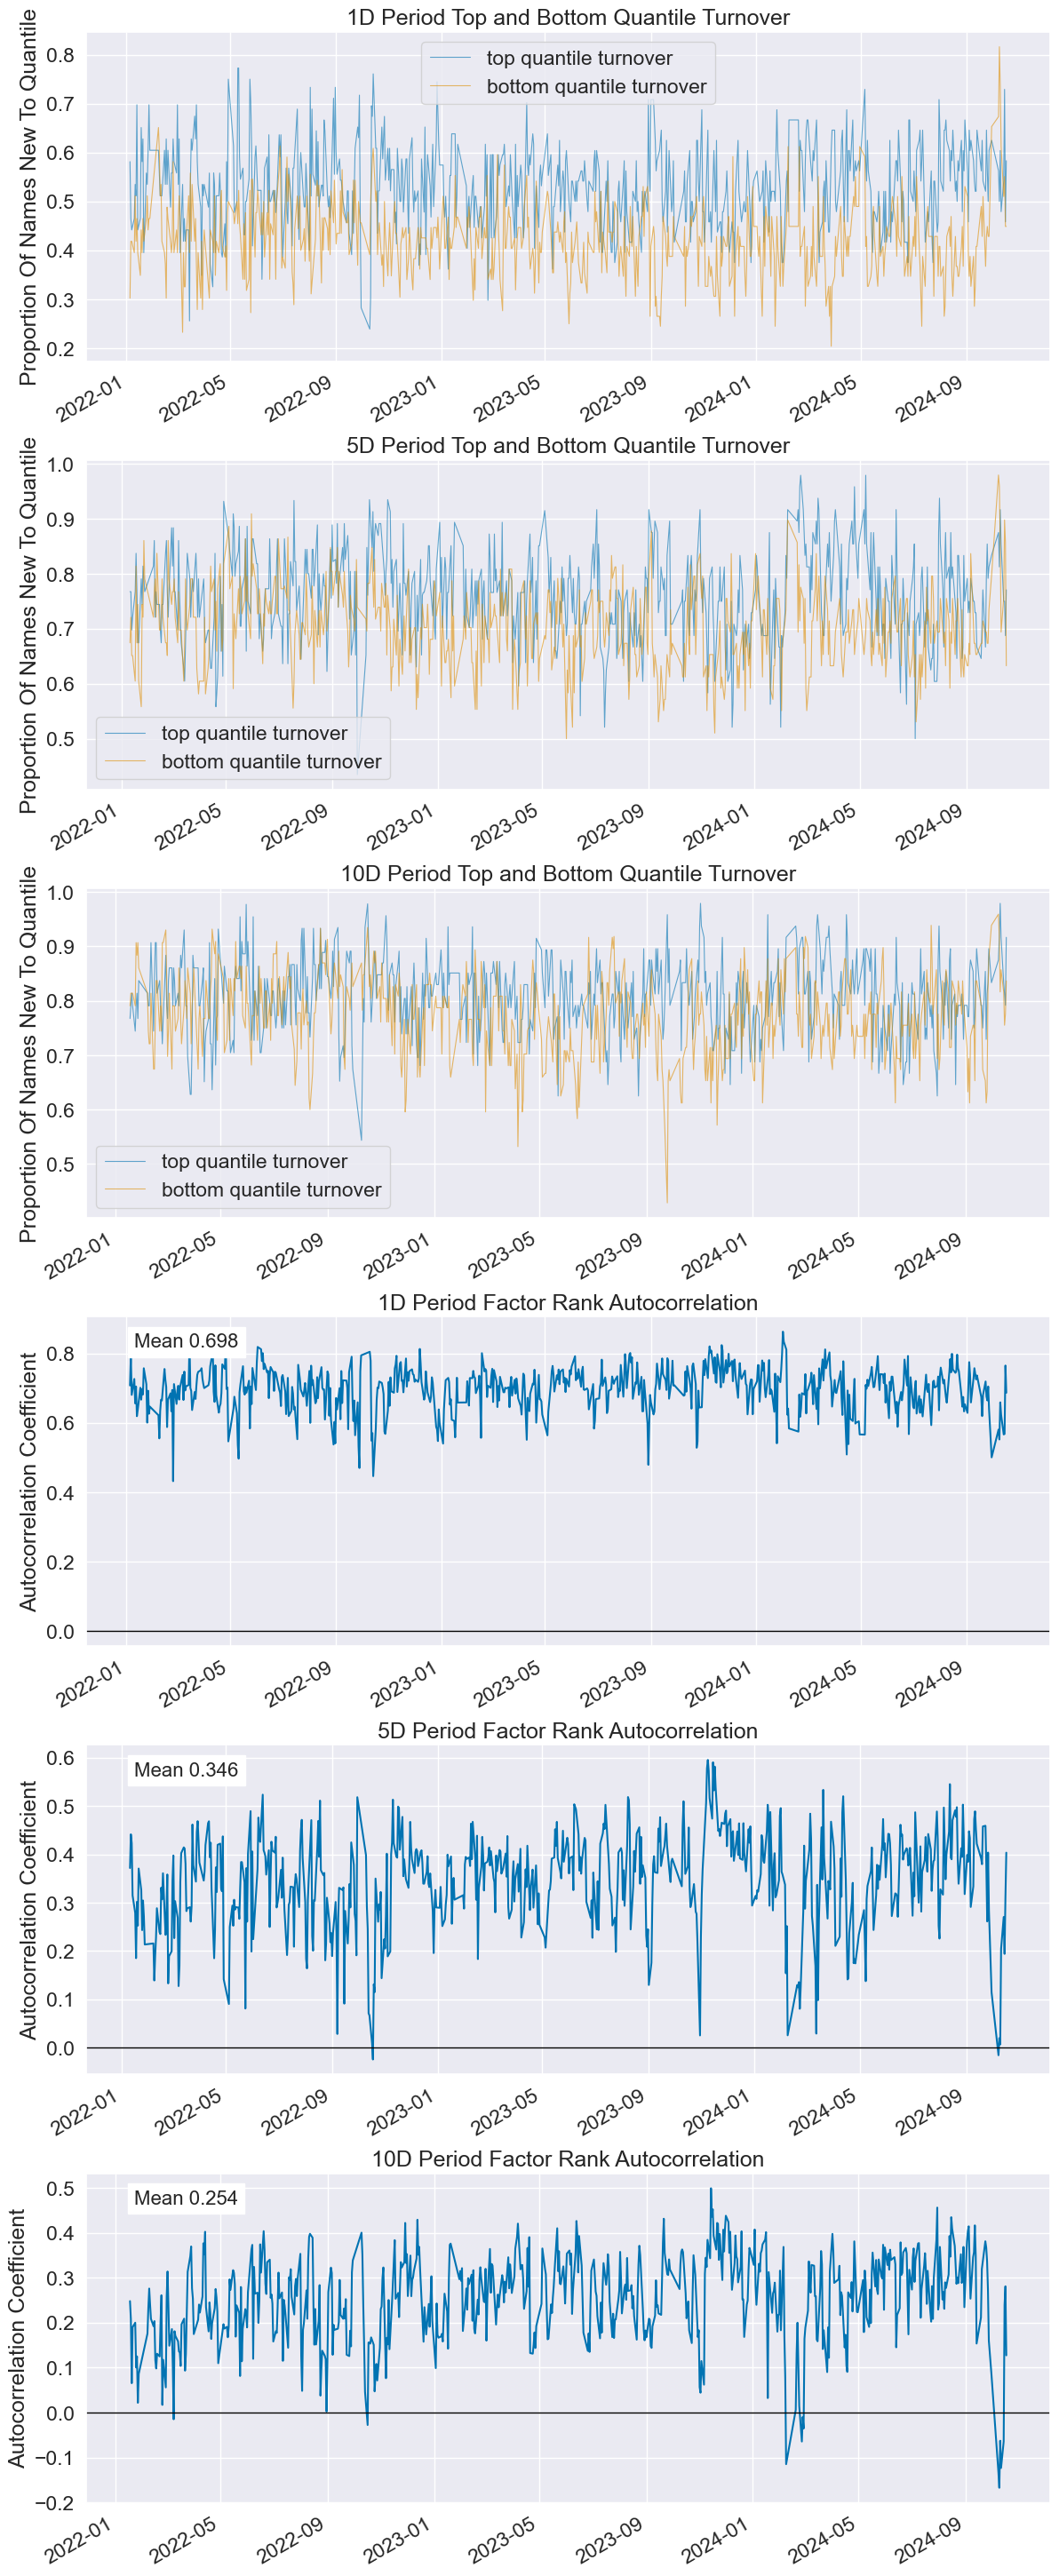

In [27]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [28]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [29]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [30]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [31]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [32]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2022, 1, 1),
    end=datetime(2024, 10, 31),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [33]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-10-22 19:02:58 开始加载历史数据


  2%|▏         | 9/500 [00:00<00:05, 87.70it/s]

extract_vt_symbol: 001228.SZSE
extract_vt_symbol: 002529.SZSE
extract_vt_symbol: 002524.SZSE
extract_vt_symbol: 002549.SZSE
extract_vt_symbol: 000566.SZSE
extract_vt_symbol: 300459.SZSE
extract_vt_symbol: 301413.SZSE
extract_vt_symbol: 600476.SSE
extract_vt_symbol: 002956.SZSE
extract_vt_symbol: 002918.SZSE
extract_vt_symbol: 002943.SZSE
extract_vt_symbol: 002005.SZSE
extract_vt_symbol: 601011.SSE
extract_vt_symbol: 301548.SZSE
extract_vt_symbol: 002135.SZSE
extract_vt_symbol: 601100.SSE
extract_vt_symbol: 002145.SZSE
extract_vt_symbol: 300260.SZSE
extract_vt_symbol: 002020.SZSE
extract_vt_symbol: 600337.SSE
extract_vt_symbol: 300122.SZSE
extract_vt_symbol: 000591.SZSE
extract_vt_symbol: 603058.SSE


  5%|▌         | 25/500 [00:00<00:03, 120.11it/s]

extract_vt_symbol: 300655.SZSE
extract_vt_symbol: 002853.SZSE
extract_vt_symbol: 300480.SZSE
extract_vt_symbol: 600241.SSE
extract_vt_symbol: 002141.SZSE
extract_vt_symbol: 000811.SZSE
extract_vt_symbol: 301040.SZSE
extract_vt_symbol: 300559.SZSE
extract_vt_symbol: 603439.SSE
extract_vt_symbol: 600101.SSE
extract_vt_symbol: 600859.SSE
extract_vt_symbol: 603826.SSE
extract_vt_symbol: 600740.SSE
extract_vt_symbol: 300788.SZSE
extract_vt_symbol: 003035.SZSE
extract_vt_symbol: 300121.SZSE
extract_vt_symbol: 300720.SZSE
2025-10-22 19:02:58 File lab/csi300/daily/301678.SZSE.parquet does not exist


...

 94%|█████████▍| 471/500 [00:02<00:00, 202.40it/s]

extract_vt_symbol: 002726.SZSE
extract_vt_symbol: 688484.SSE
extract_vt_symbol: 600063.SSE
extract_vt_symbol: 300937.SZSE
extract_vt_symbol: 002368.SZSE
extract_vt_symbol: 002649.SZSE
extract_vt_symbol: 600821.SSE
extract_vt_symbol: 603608.SSE
extract_vt_symbol: 601609.SSE
extract_vt_symbol: 601827.SSE
extract_vt_symbol: 000731.SZSE
extract_vt_symbol: 000951.SZSE
extract_vt_symbol: 002813.SZSE
extract_vt_symbol: 300449.SZSE
extract_vt_symbol: 605033.SSE
extract_vt_symbol: 300942.SZSE
extract_vt_symbol: 688322.SSE
extract_vt_symbol: 603203.SSE
extract_vt_symbol: 002926.SZSE
extract_vt_symbol: 300256.SZSE
extract_vt_symbol: 688051.SSE
extract_vt_symbol: 000728.SZSE
extract_vt_symbol: 605228.SSE
extract_vt_symbol: 688710.SSE
extract_vt_symbol: 603551.SSE
extract_vt_symbol: 002007.SZSE
extract_vt_symbol: 300890.SZSE
extract_vt_symbol: 603599.SSE
extract_vt_symbol: 300437.SZSE
extract_vt_symbol: 600200.SSE
extract_vt_symbol: 300900.SZSE
extract_vt_symbol: 002213.SZSE
extract_vt_symbol: 3007

100%|██████████| 500/500 [00:02<00:00, 195.01it/s]

extract_vt_symbol: 300800.SZSE
extract_vt_symbol: 002959.SZSE
extract_vt_symbol: 001203.SZSE
extract_vt_symbol: 688408.SSE
extract_vt_symbol: 603733.SSE
extract_vt_symbol: 603096.SSE
2025-10-22 19:03:01 部分合约历史数据为空：['301678.SZSE', '603202.SSE', '301560.SZSE', '603124.SSE', '301622.SZSE', '001390.SZSE', '688411.SSE', '603406.SSE']
2025-10-22 19:03:01 所有历史数据加载完成，共492个合约
2025-10-22 19:03:01 策略初始化完成
2025-10-22 19:03:01 开始回放历史数据


extract_vt_symbol: 600241.SSE
extract_vt_symbol: 688199.SSE
extract_vt_symbol: 603879.SSE
extract_vt_symbol: 688278.SSE
extract_vt_symbol: 688178.SSE
extract_vt_symbol: 689009.SSE
extract_vt_symbol: 688208.SSE
extract_vt_symbol: 600421.SSE
extract_vt_symbol: 688700.SSE
extract_vt_symbol: 300717.SZSE
extract_vt_symbol: 000661.SZSE
extract_vt_symbol: 601077.SSE
extract_vt_symbol: 600498.SSE
extract_vt_symbol: 603515.SSE
extract_vt_symbol: 601988.SSE
extract_vt_symbol: 600612.SSE
extract_vt_symbol: 688528.SSE
extract_vt_symbol: 300759.SZSE
extract_vt_symbol: 002008.SZSE
extract_vt_symbol: 600028.SSE
extract_vt_symbol: 600739.SSE
extract_vt_symbol: 601989.SSE
extract_vt_symbol: 600518.SSE
extract_vt_symbol: 601766.SSE
extract_vt_symbol: 688309.SSE
extract_vt_symbol: 603823.SSE
extract_vt_symbol: 003031.SZSE
extract_vt_symbol: 300890.SZSE
extract_vt_symbol: 600933.SSE
extract_vt_symbol: 688408.SSE
extract_vt_symbol: 300622.SZSE
extract_vt_symbol: 002086.SZSE
extract_vt_symbol: 688276.SSE
ex

In [34]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)

2025-10-22 19:03:03 File lab/csi300/daily/000300.SSE.parquet does not exist


ShapeError: unable to add a column of length 0 to a DataFrame of height 683